# Data Sampling

# Libraries

In [134]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

In [135]:
# Pour que les graphes s'affichent bien dans le notebook
%matplotlib inline

# Options d'affichage pandas
pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 120)

# Randomized sample

Fenêtre de vision du dataset

In [136]:
filename = "X_2025/programmatic_publisher.csv"
N = 1000  # taille du sample

In [137]:
chunksize = 50000  # ajuste si tu veux
total_rows = 0

In [138]:
# Lire les noms de colonnes (0 RAM)
columns = pd.read_csv(filename, nrows=0).columns

sample = []

for chunk in pd.read_csv(filename, chunksize=chunksize):
    total_rows += len(chunk)
    
    # Probabilité de tirer une ligne du chunk
    frac = N / total_rows
    
    if frac > 1:
        frac = 1  # sécurité
    
    sampled_chunk = chunk.sample(frac=frac, random_state=None)
    sample.append(sampled_chunk)

# Concaténer tous les tirages, puis en sélectionner exactement 1000
sample = pd.concat(sample).sample(n=N, random_state=42)

sample.to_csv("programmatic_sample_1000.csv", index=False)

print("Done!")

Done!


# 1. Chargement des données

In [139]:
RETAILER_PATH = "X_2025/retailer.csv"
TV_PATH = "X_2025/tv_publisher.csv"
PROG_PATH = "X_2025/programmatic_publisher.csv"
MAPPING_PATH = "X_2025/mapping_transac_publisher_tv.csv"
SOCIO_PATH = "X_2025/socio_demo.csv"

In [140]:
# Chargement
retailer = pd.read_csv(RETAILER_PATH)
tv = pd.read_csv(TV_PATH)
prog = pd.read_csv(PROG_PATH)
mapping = pd.read_csv(MAPPING_PATH)
socio = pd.read_csv(SOCIO_PATH)

In [141]:
# Aperçu rapide
print("Retailer :")
display(retailer.head())

print("\nTV publisher :")
display(tv.head())

print("\nProgrammatic publisher :")
display(prog.head())

print("\nMapping :")
display(mapping.head())

print("\nSocio-démo :")
display(socio.head())

Retailer :


,customer_id,timestamp_utc,event_name,brand,product_name,sales,quantity
0,reFs5GI87lXJkJSi9r,2024-02-07 02:27:10,Product Page View,NaN,NaN,NaN,NaN
1,reFs5GI87lXJkJSi9r,2024-06-12 16:16:54,Product Page View,Science Diet,SD Fel A7+ SavCknEnt 24x5.5oz cs,NaN,NaN
2,reTjziox2cSrxVq70Y,2024-02-28 04:11:46,Product Page View,NaN,NaN,NaN,NaN
3,reTjziox2cSrxVq70Y,2024-02-28 04:30:42,Product Page View,Science Diet,SD Fel Adt HBC OFEnt 24x5.5oz cs,NaN,NaN
4,reOrpt9vhSwhbPVtni,2024-06-01 22:22:30,Product Page View,NaN,NaN,NaN,NaN



TV publisher :


,device_id,timestamp_utc,cost_milli_cent
0,ctv81YlbBXho,2024-04-23 21:09:46,2325.51
1,ctvWr7bOO5Je,2024-04-19 18:31:30,2325.51
2,ctvktBqDUgcV,2024-05-07 23:32:37,2325.51
3,ctv4bFFpBJms,2024-06-28 00:10:10,2325.51
4,ctvFZB9pUMZ7,2024-05-24 03:45:45,2325.51



Programmatic publisher :


,dsp_id,timestamp_utc,campaign_name,device_type,cost_milli_cent
0,dsp9tnGII5BeXbn6LUSFZPcKGCyI0F,2024-02-06 04:10:41,Contextual,Phone,283.496
1,dsp1hXcI9Q6TZYzLEmeTkxzhjqD6HJ,2024-02-26 23:49:23,Retargeting,PC,1884.537
2,dspcd3UcXUcUk0PEo2hb8CEH3WVlFE,2024-06-16 20:55:27,Contextual,TV,601.930
3,dspSnORtuQRLSkZKp9nbSIpbJBQLP1,2024-06-26 19:15:54,Contextual,TV,1191.750
4,dspSnORtuQRLSkZKp9nbSIpbJBQLP1,2024-05-31 18:38:54,Retargeting,TV,739.262



Mapping :


,customer_id,dsp_id,device_id
0,reFs5GI87lXJkJSi9r,dsp9tnGII5BeXbn6LUSFZPcKGCyI0F,ctv81YlbBXho
1,reTjziox2cSrxVq70Y,dspCSu1n1mhys37Na5OXMaKaE8P8CS,ctvHmkxqZXBg
2,reOrpt9vhSwhbPVtni,dsp1hXcI9Q6TZYzLEmeTkxzhjqD6HJ,ctvwp5n34myx
3,reutQ3jiBX9Li4Ggqi,dspcd3UcXUcUk0PEo2hb8CEH3WVlFE,ctvdkYC70D2x
4,reH7UgH29AreRh8wWy,dspSnORtuQRLSkZKp9nbSIpbJBQLP1,ctvTgbqnhRd8



Socio-démo :


,customer_id,breed,age,income
0,rezLh5Hae3m6flaxM4,Purebred,[25-35[,[120-200K$[
1,resWkHpEcL1IUfdoBp,Purebred,[25-35[,[80-120K$[
2,re9qxF7kS9R2LwOVVY,Purebred,[35-45[,[80-120K$[
3,re3IZNYZY6xr8OAE56,Purebred,[55-65[,[40-80K$[
4,re01lnV2DfgMLdfIF7,Purebred,[65+[,[80-120K$[


# 2. Prétraitement de base

In [142]:
# Conversion des timestamps
for df, name in [(retailer, "retailer"), (tv, "tv"), (prog, "prog")]:
    if "timestamp_utc" in df.columns:
        df["timestamp_utc"] = pd.to_datetime(df["timestamp_utc"], utc=True, errors="coerce")
        df["date"] = df["timestamp_utc"].dt.date  # uniquement la date (sans husde)
        print(f"Colonnes temps traitées pour {name}")

# Conversion cost_milli_cent à USD
def millicent_to_usd(series):
    # 1 millicent = 0.00001 $
    return series * 0.00001

if "cost_milli_cent" in tv.columns:
    tv["cost_usd"] = millicent_to_usd(tv["cost_milli_cent"])

if "cost_milli_cent" in prog.columns:
    prog["cost_usd"] = millicent_to_usd(prog["cost_milli_cent"])

Colonnes temps traitées pour retailer
Colonnes temps traitées pour tv
Colonnes temps traitées pour prog


# 3. Construction de la table client intégrée

## 3.1 Agrégation des transactions par client

In [143]:
transactions_by_customer = (
    retailer
    .groupby("customer_id", as_index=False)
    .agg(
        total_sales=("sales", "sum"),
        total_quantity=("quantity", "sum"),
        n_exposure=("timestamp_utc", "count"),
        first_purchase=("timestamp_utc", "min"),
        last_purchase=("timestamp_utc", "max"),
    )
)

print("Transactions agrégées par client :")
display(transactions_by_customer.head())

Transactions agrégées par client :


,customer_id,total_sales,total_quantity,n_exposure,first_purchase,last_purchase
0,re0007V8sqIHsZnbvC,0.00,0.0,2,2024-01-29 23:46:22+00:00,2024-01-29 23:54:51+00:00
1,re000JYhnKbTkPqMB4,0.00,0.0,3,2024-01-08 06:10:19+00:00,2024-01-08 06:39:11+00:00
2,re000fIO9QXTWYjOfn,284.52,8.0,23,2024-01-24 14:44:47+00:00,2024-06-21 22:13:02+00:00
3,re000kbtVVzPwZcEr4,0.00,0.0,19,2024-03-06 23:57:04+00:00,2024-05-25 04:17:44+00:00
4,re000pHbVOysCXRHgt,394.94,5.0,17,2024-01-01 18:12:21+00:00,2024-06-08 12:43:06+00:00


## 3.2 Exposition TV par client
1. On joint `mapping` avec `tv` sur `device_id`  
2. On agrège par `customer_id`

In [144]:
print("Taille mapping :", mapping.shape)
print("Taille tv :", tv.shape)

print("\nNb de device_id uniques dans mapping :", mapping["device_id"].nunique())
print("Nb de device_id uniques dans tv :", tv["device_id"].nunique())

Taille mapping : (7984411, 3)
Taille tv : (5827133, 5)

Nb de device_id uniques dans mapping : 7593089
Nb de device_id uniques dans tv : 2065539


In [145]:
# 1) On agrège les impressions TV par device_id
tv_by_device = (
    tv
    .groupby("device_id", as_index=False)
    .agg(
        tv_impressions_device=("timestamp_utc", "count"),
        tv_cost_usd_device=("cost_usd", "sum"),
    )
)

print("TV agrégé par device :")
display(tv_by_device.head())

# 2) On joint cette table agrégée avec le mapping (customer_id, device_id)
tv_customer_device = (
    mapping
    .merge(tv_by_device, on="device_id", how="left")
)

print("Jointure mapping + TV agrégé :")
display(tv_customer_device.head())

# 3) On agrège ensuite par customer_id
tv_by_customer = (
    tv_customer_device
    .groupby("customer_id", as_index=False)
    .agg(
        tv_impressions=("tv_impressions_device", "sum"),
        tv_cost_usd=("tv_cost_usd_device", "sum"),
    )
)

# Remplacer NaN par 0
tv_by_customer["tv_impressions"] = tv_by_customer["tv_impressions"].fillna(0).astype(int)
tv_by_customer["tv_cost_usd"] = tv_by_customer["tv_cost_usd"].fillna(0)

print("Exposition TV par client :")
display(tv_by_customer.head())

TV agrégé par device :


,device_id,tv_impressions_device,tv_cost_usd_device
0,ctv000660oW2,8,0.186041
1,ctv0009WN4ln,1,0.023255
2,ctv000B2hyqf,2,0.046510
3,ctv000CWaqYi,1,0.023255
4,ctv000DU8ESX,1,0.023255


Jointure mapping + TV agrégé :


,customer_id,dsp_id,device_id,tv_impressions_device,tv_cost_usd_device
0,reFs5GI87lXJkJSi9r,dsp9tnGII5BeXbn6LUSFZPcKGCyI0F,ctv81YlbBXho,1.0,0.023255
1,reTjziox2cSrxVq70Y,dspCSu1n1mhys37Na5OXMaKaE8P8CS,ctvHmkxqZXBg,NaN,NaN
2,reOrpt9vhSwhbPVtni,dsp1hXcI9Q6TZYzLEmeTkxzhjqD6HJ,ctvwp5n34myx,NaN,NaN
3,reutQ3jiBX9Li4Ggqi,dspcd3UcXUcUk0PEo2hb8CEH3WVlFE,ctvdkYC70D2x,NaN,NaN
4,reH7UgH29AreRh8wWy,dspSnORtuQRLSkZKp9nbSIpbJBQLP1,ctvTgbqnhRd8,NaN,NaN


Exposition TV par client :


,customer_id,tv_impressions,tv_cost_usd
0,re0000ojYmqRl7rUnS,25,0.581378
1,re00028YNnes2ALX3p,4,0.093020
2,re0003BIjfgvMOXmfh,0,0.000000
3,re0004JIBEIySuLwvj,1,0.023255
4,re0007V8sqIHsZnbvC,0,0.000000


## 3.3 Exposition Programmatic par client

1. Jointure `mapping` ↔ `prog` sur `dsp_id`  
2. Agrégation par `customer_id`

In [146]:
# 1) On agrège les impressions programmatic par dsp_id
prog_by_dsp = (
    prog
    .groupby("dsp_id", as_index=False)
    .agg(
        prog_impressions_dsp=("timestamp_utc", "count"),
        prog_cost_usd_dsp=("cost_usd", "sum"),
    )
)

print("Programmatic agrégé par dsp_id :")
display(prog_by_dsp.head())

# 2) On joint cette table agrégée avec le mapping (customer_id, dsp_id)
prog_customer_dsp = (
    mapping
    .merge(prog_by_dsp, on="dsp_id", how="left")
)

print("Jointure mapping + Programmatic agrégé :")
display(prog_customer_dsp.head())

# 3) On agrège ensuite par customer_id
prog_by_customer = (
    prog_customer_dsp
    .groupby("customer_id", as_index=False)
    .agg(
        prog_impressions=("prog_impressions_dsp", "sum"),
        prog_cost_usd=("prog_cost_usd_dsp", "sum"),
    )
)

# Remplacer NaN par 0
prog_by_customer["prog_impressions"] = prog_by_customer["prog_impressions"].fillna(0).astype(int)
prog_by_customer["prog_cost_usd"] = prog_by_customer["prog_cost_usd"].fillna(0)

print("Exposition Programmatic par client :")
display(prog_by_customer.head())

Programmatic agrégé par dsp_id :


,dsp_id,prog_impressions_dsp,prog_cost_usd_dsp
0,dsp0000zgOGRGzNXlFGuswTD8LV6xA,2,0.009119
1,dsp00040djIAqe73TjNJ1CFKw0K4eu,1,0.043323
2,dsp0006CxEoblczDFJSqDw5BiCtNi6,1,0.003397
3,dsp0006ipUFLA8MoTsAx83XZ11T5hl,1,0.001445
4,dsp0008hWrKfZuquMQaJQrp8FQyKK6,2,0.002819


Jointure mapping + Programmatic agrégé :


,customer_id,dsp_id,device_id,prog_impressions_dsp,prog_cost_usd_dsp
0,reFs5GI87lXJkJSi9r,dsp9tnGII5BeXbn6LUSFZPcKGCyI0F,ctv81YlbBXho,1.0,0.002835
1,reTjziox2cSrxVq70Y,dspCSu1n1mhys37Na5OXMaKaE8P8CS,ctvHmkxqZXBg,NaN,NaN
2,reOrpt9vhSwhbPVtni,dsp1hXcI9Q6TZYzLEmeTkxzhjqD6HJ,ctvwp5n34myx,1.0,0.018845
3,reutQ3jiBX9Li4Ggqi,dspcd3UcXUcUk0PEo2hb8CEH3WVlFE,ctvdkYC70D2x,1.0,0.006019
4,reH7UgH29AreRh8wWy,dspSnORtuQRLSkZKp9nbSIpbJBQLP1,ctvTgbqnhRd8,3.0,0.020845


Exposition Programmatic par client :


,customer_id,prog_impressions,prog_cost_usd
0,re0000ojYmqRl7rUnS,0,0.000000
1,re00028YNnes2ALX3p,1907730,10146.831610
2,re0003BIjfgvMOXmfh,1,0.001468
3,re0004JIBEIySuLwvj,0,0.000000
4,re0007V8sqIHsZnbvC,0,0.000000


In [147]:
customers = customers[customers["customer_id"] != "unknown"].copy()

## 3.4 Jointure socio-démo

In [148]:
# On suppose que socio contient : customer_id, age, income, breed
socio_demo = socio.copy()

print("Socio-démo :")
display(socio_demo.head())

Socio-démo :


,customer_id,breed,age,income
0,rezLh5Hae3m6flaxM4,Purebred,[25-35[,[120-200K$[
1,resWkHpEcL1IUfdoBp,Purebred,[25-35[,[80-120K$[
2,re9qxF7kS9R2LwOVVY,Purebred,[35-45[,[80-120K$[
3,re3IZNYZY6xr8OAE56,Purebred,[55-65[,[40-80K$[
4,re01lnV2DfgMLdfIF7,Purebred,[65+[,[80-120K$[


## 3.5 Table client finale

On joint :
- transactions_by_customer
- tv_by_customer
- prog_by_customer
- socio_demo

In [149]:
# Jointures successives sur customer_id
customers = (
    transactions_by_customer
    .merge(tv_by_customer, on="customer_id", how="left")
    .merge(prog_by_customer, on="customer_id", how="left")
    .merge(socio_demo, on="customer_id", how="left")
)

# Remplacer NaN restants pour les expos par 0
for col in ["tv_impressions", "tv_cost_usd", "prog_impressions", "prog_cost_usd"]:
    if col in customers.columns:
        customers[col] = customers[col].fillna(0)

print("Table client finale :")
display(customers.head())
print(f"Nombre total de clients : {len(customers)}")

Table client finale :


,customer_id,total_sales,total_quantity,n_exposure,first_purchase,last_purchase,tv_impressions,tv_cost_usd,prog_impressions,prog_cost_usd,breed,age,income
0,re0007V8sqIHsZnbvC,0.00,0.0,2,2024-01-29 23:46:22+00:00,2024-01-29 23:54:51+00:00,0,0.0,0,0.000000,Purebred,[25-35[,[120-200K$[
1,re000JYhnKbTkPqMB4,0.00,0.0,3,2024-01-08 06:10:19+00:00,2024-01-08 06:39:11+00:00,0,0.0,0,0.000000,Mixed-breed,[18-25[,[120-200K$[
2,re000fIO9QXTWYjOfn,284.52,8.0,23,2024-01-24 14:44:47+00:00,2024-06-21 22:13:02+00:00,0,0.0,1,0.035952,Purebred,[45-55[,[40-80K$[
3,re000kbtVVzPwZcEr4,0.00,0.0,19,2024-03-06 23:57:04+00:00,2024-05-25 04:17:44+00:00,0,0.0,0,0.000000,Purebred,[65+[,[200K$+[
4,re000pHbVOysCXRHgt,394.94,5.0,17,2024-01-01 18:12:21+00:00,2024-06-08 12:43:06+00:00,0,0.0,1,0.018635,Purebred,[18-25[,[120-200K$[


Nombre total de clients : 1354584


# 4. Création de segments d'exposition (TV / Programmatic / Mixte / Non exposés)

In [150]:
# Flags d'exposition
customers["exposed_tv"] = customers["tv_impressions"] > 0
customers["exposed_prog"] = customers["prog_impressions"] > 0

# Création d'un segment par combinaison d'exposition
conditions = [
    (customers["exposed_tv"]) & (customers["exposed_prog"]),
    (customers["exposed_tv"]) & (~customers["exposed_prog"]),
    (~customers["exposed_tv"]) & (customers["exposed_prog"]),
]
labels = [
    "Multi-canal (TV + Prog)",
    "TV only",
    "Prog only",
]

customers["segment_expo"] = np.select(conditions, labels, default="Non exposé")

customers["segment_expo"].value_counts()

segment_expo
Prog only                  785062
Non exposé                 415828
TV only                     80657
Multi-canal (TV + Prog)     73037
Name: count, dtype: int64

# 5. KPIs par segment : CA, panier, fréquence

On va comparer :
- le chiffre d'affaires
- le panier moyen
- le nombre de transactions
entre les différents segments d'exposition.

In [151]:
# Renommer pour être cohérent avec les KPIs
if "n_exposure" in customers.columns:
    customers = customers.rename(columns={"n_exposure": "n_transactions"})

In [152]:
kpi_segment = (
    customers
    .groupby("segment_expo", as_index=False)
    .agg(
        clients=("customer_id", "nunique"),
        total_sales=("total_sales", "sum"),
        mean_sales_per_client=("total_sales", "mean"),
        mean_transactions=("n_transactions", "mean"),
    )
    .sort_values("total_sales", ascending=False)
)

print("KPIs par segment d'exposition :")
display(kpi_segment)

KPIs par segment d'exposition :


,segment_expo,clients,total_sales,mean_sales_per_client,mean_transactions
2,Prog only,785062,35707399.45,45.483541,7.716692
1,Non exposé,415828,19438871.84,46.747386,6.697320
3,TV only,80657,3777760.09,46.837349,5.964058
0,Multi-canal (TV + Prog),73037,3503917.80,47.974558,7.420773


## 5.1 Graphique : CA total par segment

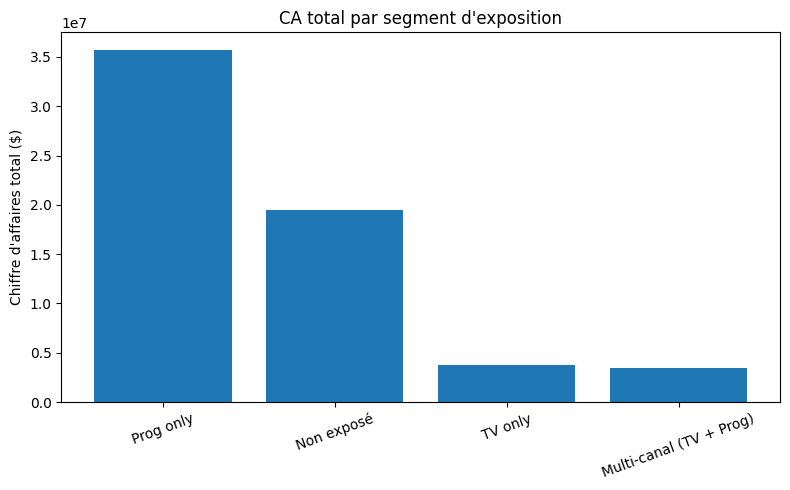

In [153]:
plt.figure(figsize=(8, 5))
plt.bar(kpi_segment["segment_expo"], kpi_segment["total_sales"])
plt.xticks(rotation=20)
plt.ylabel("Chiffre d'affaires total ($)")
plt.title("CA total par segment d'exposition")
plt.tight_layout()
plt.show()

## 5.2 Graphique : panier moyen par segment

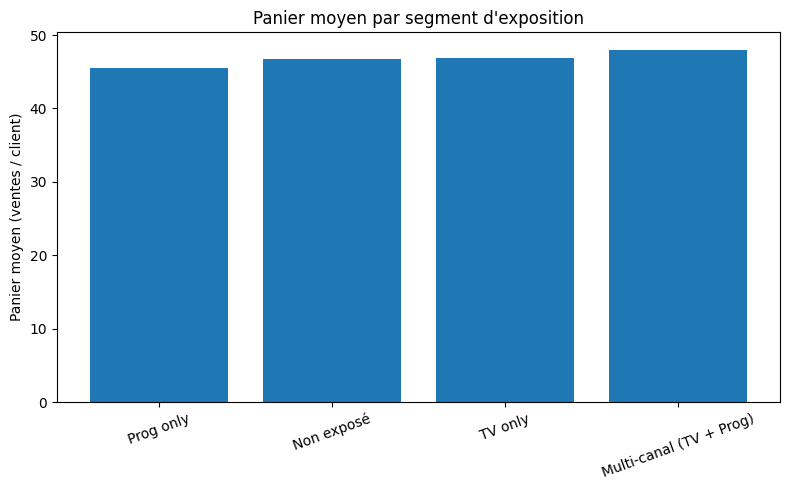

In [154]:
plt.figure(figsize=(8, 5))
plt.bar(kpi_segment["segment_expo"], kpi_segment["mean_sales_per_client"])
plt.xticks(rotation=20)
plt.ylabel("Panier moyen (ventes / client)")
plt.title("Panier moyen par segment d'exposition")
plt.tight_layout()
plt.show()

# 6. Timeline : dépenses pub vs ventes

On agrège :
 - ventes par jour
 - coûts TV par jour
 - coûts Programmatic par jour

 Puis on affiche sur un même graphique (avec 2 axes Y).

## 6.1 Ventes par jour

In [155]:

sales_per_day = (
    retailer
    .groupby("date", as_index=False)
    .agg(sales_day=("sales", "sum"))
)

## 6.2 Coût TV par jour

In [156]:

tv_cost_per_day = (
    tv
    .groupby("date", as_index=False)
    .agg(tv_cost_day=("cost_usd", "sum"))
)

## 6.3 Coût Programmatic par jour

In [157]:

prog_cost_per_day = (
    prog
    .groupby("date", as_index=False)
    .agg(prog_cost_day=("cost_usd", "sum"))
)


In [158]:
# Jointure sur la date
timeline = (
    sales_per_day
    .merge(tv_cost_per_day, on="date", how="outer")
    .merge(prog_cost_per_day, on="date", how="outer")
    .sort_values("date")
)

timeline = timeline.fillna(0)

print("Timeline (ventes + coûts pub) :")
display(timeline.head())

Timeline (ventes + coûts pub) :


,date,sales_day,tv_cost_day,prog_cost_day
0,2024-01-01,281964.81,0.0,536.282783
1,2024-01-02,383758.79,0.0,651.042506
2,2024-01-03,371234.81,0.0,656.963998
3,2024-01-04,374448.78,0.0,643.749798
4,2024-01-05,367544.08,0.0,641.583927


## 6.4 Graphique : ventes vs dépenses pub (TV + Programmatic)

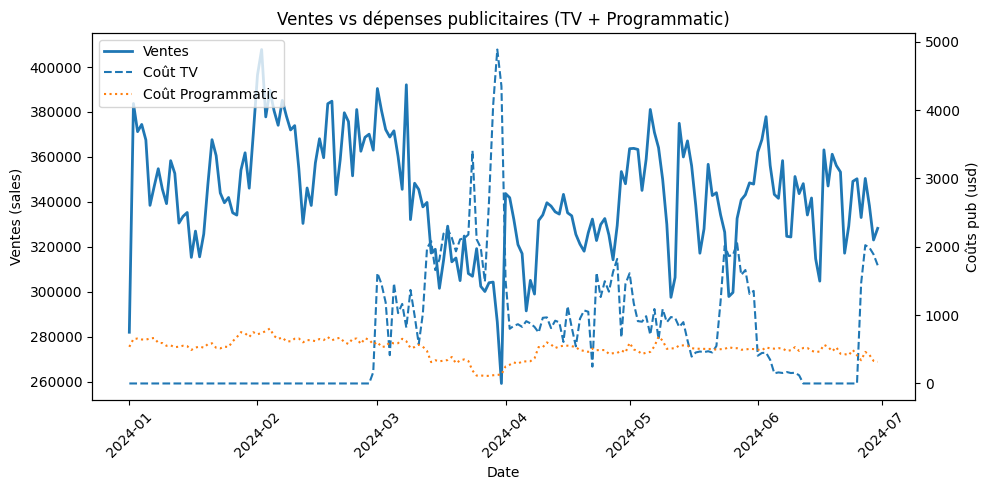

In [159]:
fig, ax1 = plt.subplots(figsize=(10, 5))

# Axe 1 : ventes
ax1.plot(timeline["date"], timeline["sales_day"], label="Ventes", linewidth=2)
ax1.set_xlabel("Date")
ax1.set_ylabel("Ventes (sales)")
ax1.tick_params(axis='x', rotation=45)

# Axe 2 : coûts pub
ax2 = ax1.twinx()
ax2.plot(timeline["date"], timeline["tv_cost_day"], linestyle='--', label="Coût TV")
ax2.plot(timeline["date"], timeline["prog_cost_day"], linestyle=':', label="Coût Programmatic")
ax2.set_ylabel("Coûts pub (usd)")

# Légendes combinées
lines, labels = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines + lines2, labels + labels2, loc="upper left")

plt.title("Ventes vs dépenses publicitaires (TV + Programmatic)")
plt.tight_layout()
plt.show()

# 7. Analyse socio-démo

On utilise directement les catégories déjà présentes :
- age : ex. "[25-35[", "[35-45[", "[65+[", etc.
- income : ex. "[40-80K$[", "[80-120K$[", "[120-200K$[", etc.

In [160]:
# Vérifier les colonnes dispo
print(customers.columns)

Index(['customer_id', 'total_sales', 'total_quantity', 'n_transactions', 'first_purchase', 'last_purchase',
       'tv_impressions', 'tv_cost_usd', 'prog_impressions', 'prog_cost_usd', 'breed', 'age', 'income', 'exposed_tv',
       'exposed_prog', 'segment_expo'],
      dtype='object')


## 7.1 KPIs par tranche d'âge (déjà catégorique)

KPIs par tranche d'âge :


,age,clients,total_sales,mean_sales
0,[18-25[,182198,7022390.45,38.542632
1,[25-35[,244938,10614446.08,43.335236
2,[35-45[,203624,13036040.67,64.020158
3,[45-55[,230629,11501201.49,49.868843
4,[55-65[,236190,10780239.59,45.642235
5,[65+[,257005,9473630.90,36.861660


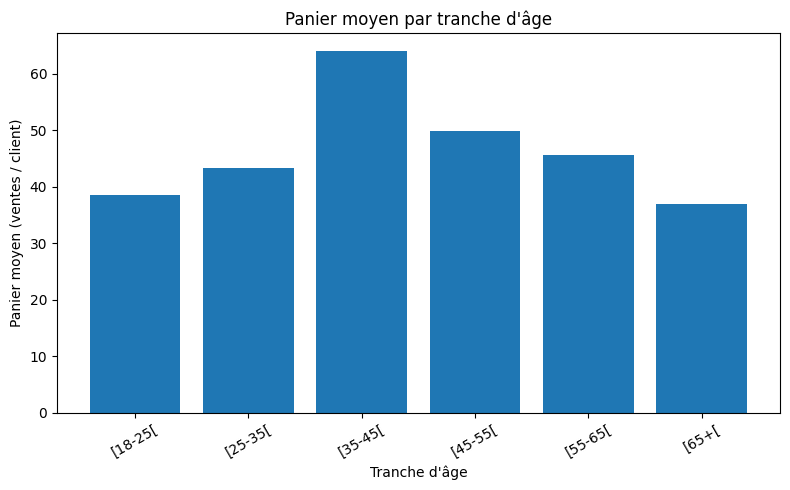

In [161]:

if "age" in customers.columns:
    kpi_age = (
        customers
        .groupby("age", as_index=False)
        .agg(
            clients=("customer_id", "nunique"),
            total_sales=("total_sales", "sum"),
            mean_sales=("total_sales", "mean"),
        )
    )

    print("KPIs par tranche d'âge :")
    display(kpi_age)

    plt.figure(figsize=(8, 5))
    plt.bar(kpi_age["age"].astype(str), kpi_age["mean_sales"])
    plt.xlabel("Tranche d'âge")
    plt.ylabel("Panier moyen (ventes / client)")
    plt.title("Panier moyen par tranche d'âge")
    plt.xticks(rotation=30)
    plt.tight_layout()
    plt.show()
else:
    print("⚠️ Colonne 'age' absente de la table customers.")

## 7.2 KPIs par tranche de revenu

KPIs par tranche de revenu :


,income,clients,total_sales,mean_sales
0,[0-40K$[,213513,13121832.13,61.456830
1,[120-200K$[,297276,12479975.62,41.981107
2,[200K$+[,284399,11306477.19,39.755685
3,[40-80K$[,279708,12839915.24,45.904712
4,[80-120K$[,279688,12679749.00,45.335334


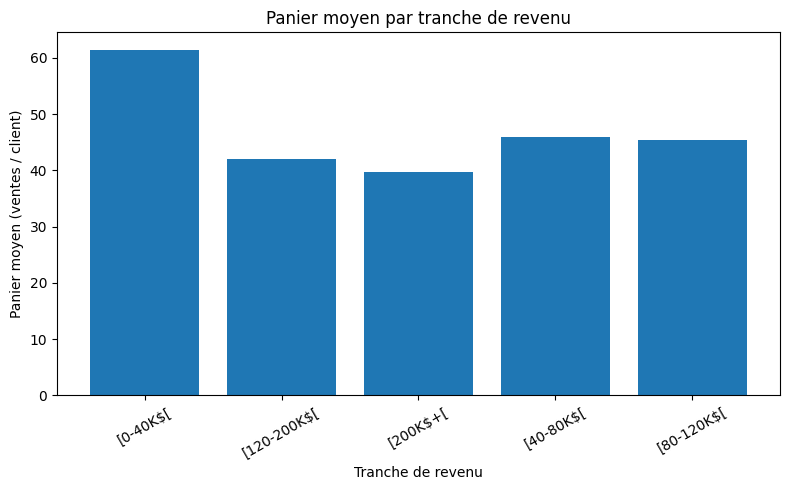

In [162]:
if "income" in customers.columns:
    kpi_income = (
        customers
        .groupby("income", as_index=False)
        .agg(
            clients=("customer_id", "nunique"),
            total_sales=("total_sales", "sum"),
            mean_sales=("total_sales", "mean"),
        )
        .sort_values("income")   # tri alphabétique des classes
    )

    print("KPIs par tranche de revenu :")
    display(kpi_income)

    plt.figure(figsize=(8, 5))
    plt.bar(kpi_income["income"].astype(str), kpi_income["mean_sales"])
    #plt.bar(kpi_income["income"].astype(str), kpi_income["total_sales"])
    plt.xlabel("Tranche de revenu")
    plt.xlabel("Tranche de revenu")
    plt.ylabel("Panier moyen (ventes / client)")
    plt.title("Panier moyen par tranche de revenu")
    plt.xticks(rotation=30)
    plt.tight_layout()
    plt.show()
else:
    print("⚠️ Colonne 'income' absente de la table customers.")


## 7.2bis Fréquence d'achat mensuelle par tranche de revenu

/var/folders/g3/5kdl364n7mv9ntsl8b3md3mr0000gn/T/ipykernel_99058/3514218758.py:11: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  retail_tx["month"] = retail_tx["timestamp_utc"].dt.to_period("M").astype(str)


Fréquence d'achat mensuelle par tranche de revenu :


,income,month,total_transactions,unique_clients,freq_per_client
0,[0-40K$[,2024-01,51178,71970,0.711102
1,[0-40K$[,2024-02,50790,70616,0.719242
2,[0-40K$[,2024-03,48977,61305,0.798907
3,[0-40K$[,2024-04,47280,59028,0.800976
4,[0-40K$[,2024-05,50810,62143,0.817630


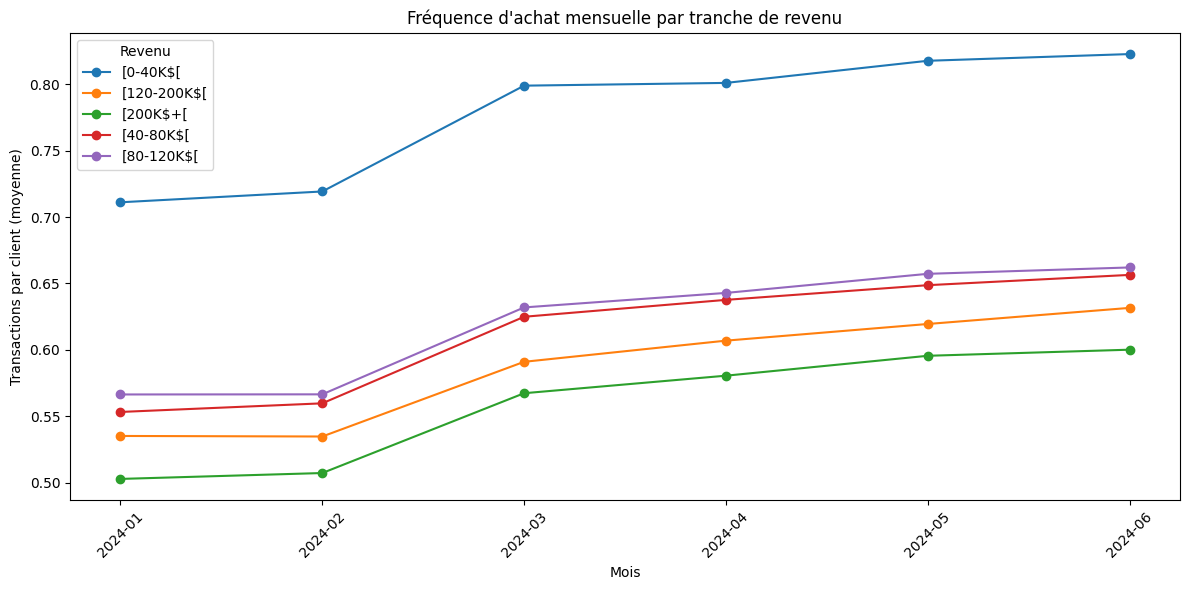

In [163]:
if "income" in customers.columns:

    # --- 1) Préparer les transactions individuelles ---
    retail_tx = retailer.merge(
        customers[["customer_id", "income"]],
        on="customer_id",
        how="left"
    ).dropna(subset=["income"])

    # Extraire année-mois au format YYYY-MM
    retail_tx["month"] = retail_tx["timestamp_utc"].dt.to_period("M").astype(str)

    # --- 2) Agréger : transactions et clients uniques par mois et par revenu ---
    freq_month_income = (
        retail_tx
        .groupby(["income", "month"], as_index=False)
        .agg(
            total_transactions=("sales", "count"),
            unique_clients=("customer_id", "nunique")
        )
        .assign(freq_per_client=lambda df: df["total_transactions"] / df["unique_clients"])
        .sort_values(["income", "month"])
    )

    print("Fréquence d'achat mensuelle par tranche de revenu :")
    display(freq_month_income.head())

    # --- 3) Visualisation ---
    plt.figure(figsize=(12, 6))

    # Un tracé par catégorie de revenu
    for inc, subset in freq_month_income.groupby("income"):
        plt.plot(subset["month"], subset["freq_per_client"], marker="o", label=str(inc))

    plt.xlabel("Mois")
    plt.ylabel("Transactions par client (moyenne)")
    plt.title("Fréquence d'achat mensuelle par tranche de revenu")
    plt.xticks(rotation=45)
    plt.legend(title="Revenu")
    plt.tight_layout()
    plt.show()

else:
    print("⚠️ Colonne 'income' absente de customers.")

## 7.3 Répartition des segments d'exposition par âge

In [164]:
if "age" in customers.columns and "segment_expo" in customers.columns:
    expo_age = (
        customers
        .groupby(["age", "segment_expo"], as_index=False)
        .agg(clients=("customer_id", "nunique"))
    )

    print("Nombre de clients par âge et segment d'exposition :")
    display(expo_age.head())

Nombre de clients par âge et segment d'exposition :


,age,segment_expo,clients
0,[18-25[,Multi-canal (TV + Prog),9820
1,[18-25[,Non exposé,54863
2,[18-25[,Prog only,106925
3,[18-25[,TV only,10590
4,[25-35[,Multi-canal (TV + Prog),13163


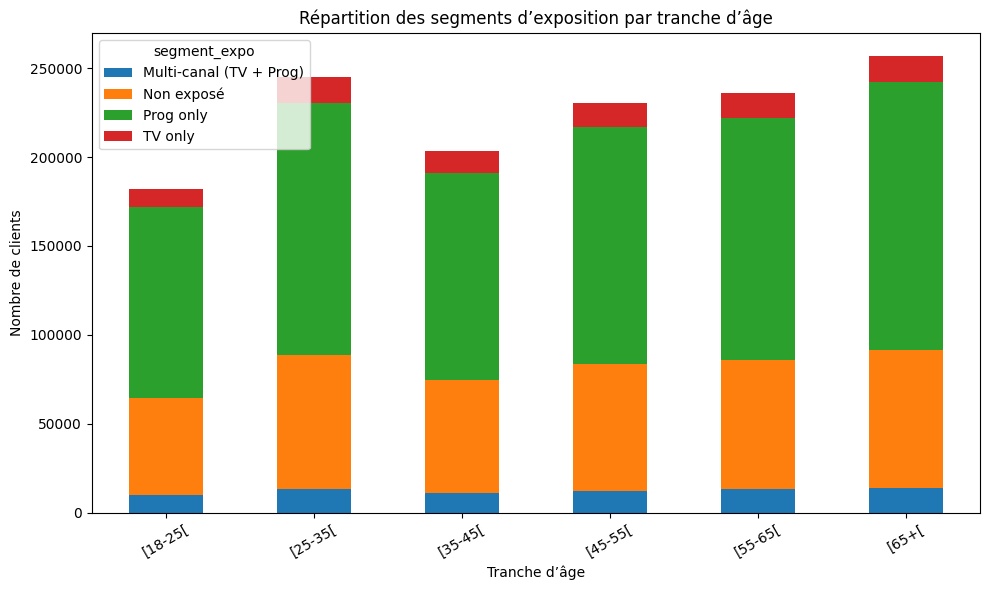

In [165]:
# Pivot : age en lignes, segments en colonnes
expo_pivot = expo_age.pivot(index="age", columns="segment_expo", values="clients").fillna(0)

# Plot
expo_pivot.plot(
    kind="bar",
    stacked=True,
    figsize=(10,6),
)

plt.title("Répartition des segments d’exposition par tranche d’âge")
plt.xlabel("Tranche d’âge")
plt.ylabel("Nombre de clients")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

### Ventes par tranche d'âge et type d'exposition

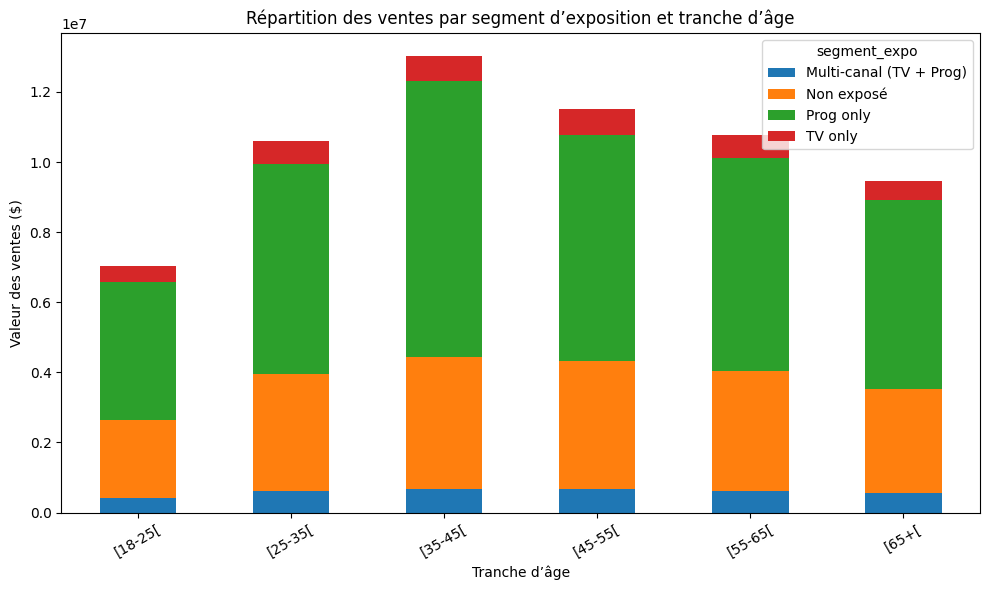

In [166]:
# Agrégation : ventes totales par tranche d'âge et segment d'exposition
sales_age = (
    customers
    .groupby(["age", "segment_expo"], as_index=False)
    .agg(total_sales=("total_sales", "sum"))
)

# Pivot : âge en lignes, segments en colonnes, valeur = ventes
sales_pivot = sales_age.pivot(
    index="age",
    columns="segment_expo",
    values="total_sales"
).fillna(0)

# Plot
sales_pivot.plot(
    kind="bar",
    stacked=True,
    figsize=(10, 6),
)

plt.title("Répartition des ventes par segment d’exposition et tranche d’âge")
plt.xlabel("Tranche d’âge")
plt.ylabel("Valeur des ventes ($)")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

### Fréquence moyenne annuelle par tranche d'âge

In [167]:
freq_year_age = (
    freq_month_age
    .groupby("age", as_index=False)
    .agg(freq_per_year=("freq_per_client", "mean"))
    .sort_values("age")
)

print("Fréquence annuelle moyenne par tranche d'âge :")
display(freq_year_age)

Fréquence annuelle moyenne par tranche d'âge :


,age,freq_per_year
0,[18-25[,0.536443
1,[25-35[,0.601271
2,[35-45[,0.718914
3,[45-55[,0.660823
4,[55-65[,0.621644
5,[65+[,0.529853


## 7.4 Analyse d'efficacité des types d'exposition

### Tracé des Ventes Prog only vs coût Programmatic

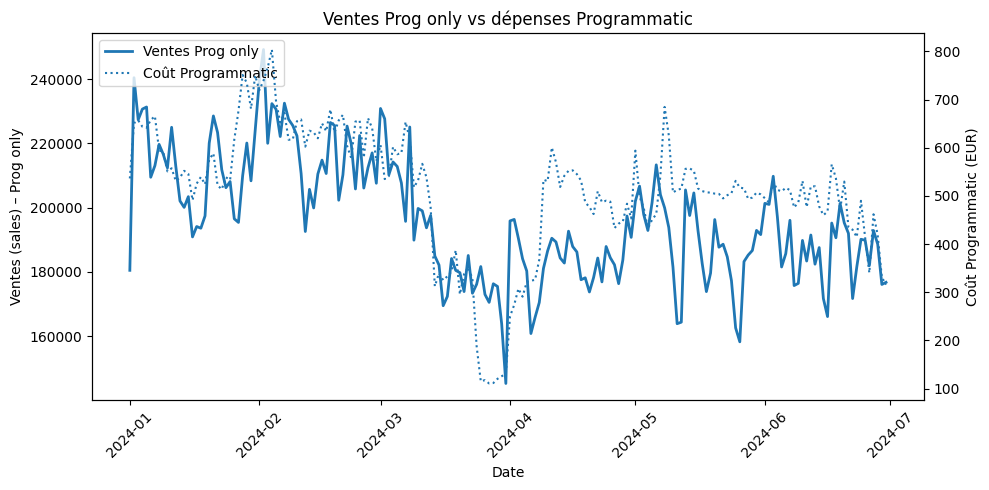

In [168]:
# Clients exposés uniquement en programmatic
prog_only_ids = customers.loc[
    customers["segment_expo"] == "Prog only", 
    "customer_id"
].unique()

# Ventes par jour pour ces clients
sales_prog_only_per_day = (
    retailer[retailer["customer_id"].isin(prog_only_ids)]
    .groupby("date", as_index=False)
    .agg(sales_day_prog_only=("sales", "sum"))
)

# Jointure avec le coût programmatic par jour
timeline_prog_only = (
    sales_prog_only_per_day
    .merge(prog_cost_per_day, on="date", how="outer")
    .sort_values("date")
    .fillna(0)
)

fig, ax1 = plt.subplots(figsize=(10, 5))

# Axe 1 : ventes Prog only
ax1.plot(
    timeline_prog_only["date"],
    timeline_prog_only["sales_day_prog_only"],
    label="Ventes Prog only",
    linewidth=2,
)
ax1.set_xlabel("Date")
ax1.set_ylabel("Ventes (sales) – Prog only")
ax1.tick_params(axis='x', rotation=45)

# Axe 2 : coûts Programmatic
ax2 = ax1.twinx()
ax2.plot(
    timeline_prog_only["date"],
    timeline_prog_only["prog_cost_day"],
    linestyle=':',
    label="Coût Programmatic",
)
ax2.set_ylabel("Coût Programmatic (EUR)")

# Légende combinée
lines, labels = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines + lines2, labels + labels2, loc="upper left")

plt.title("Ventes Prog only vs dépenses Programmatic")
plt.tight_layout()
plt.show()

### Tracé ventes TV only vs coût TV

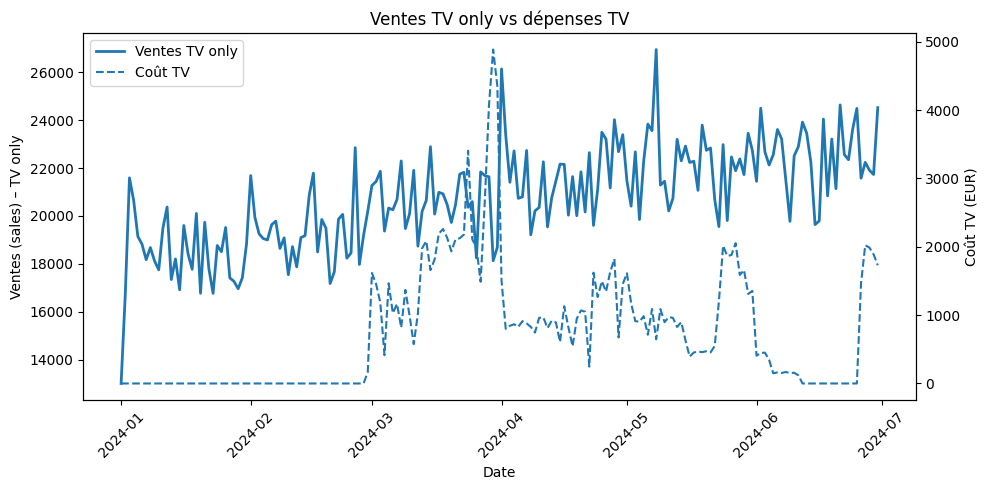

In [169]:
# Clients exposés uniquement en TV
tv_only_ids = customers.loc[
    customers["segment_expo"] == "TV only", 
    "customer_id"
].unique()

# Ventes par jour pour ces clients
sales_tv_only_per_day = (
    retailer[retailer["customer_id"].isin(tv_only_ids)]
    .groupby("date", as_index=False)
    .agg(sales_day_tv_only=("sales", "sum"))
)

# Jointure avec le coût TV par jour
timeline_tv_only = (
    sales_tv_only_per_day
    .merge(tv_cost_per_day, on="date", how="outer")
    .sort_values("date")
    .fillna(0)
)

fig, ax1 = plt.subplots(figsize=(10, 5))

# Axe 1 : ventes TV only
ax1.plot(
    timeline_tv_only["date"],
    timeline_tv_only["sales_day_tv_only"],
    label="Ventes TV only",
    linewidth=2,
)
ax1.set_xlabel("Date")
ax1.set_ylabel("Ventes (sales) – TV only")
ax1.tick_params(axis='x', rotation=45)

# Axe 2 : coûts TV
ax2 = ax1.twinx()
ax2.plot(
    timeline_tv_only["date"],
    timeline_tv_only["tv_cost_day"],
    linestyle='--',
    label="Coût TV",
)
ax2.set_ylabel("Coût TV (EUR)")

# Légende combinée
lines, labels = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines + lines2, labels + labels2, loc="upper left")

plt.title("Ventes TV only vs dépenses TV")
plt.tight_layout()
plt.show()

### Fréquence d'achat mensuelle par tranche d'âge

/var/folders/g3/5kdl364n7mv9ntsl8b3md3mr0000gn/T/ipykernel_99058/394445997.py:11: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  retail_age["month"] = retail_age["timestamp_utc"].dt.to_period("M").astype(str)


Fréquence d'achat mensuelle par tranche d'âge :


,age,month,total_transactions,unique_clients,freq_per_client
0,[18-25[,2024-01,27268,56949,0.478814
1,[18-25[,2024-02,27218,55973,0.486270
2,[18-25[,2024-03,25683,47190,0.544247
3,[18-25[,2024-04,25358,45219,0.560782
4,[18-25[,2024-05,27089,47346,0.572150


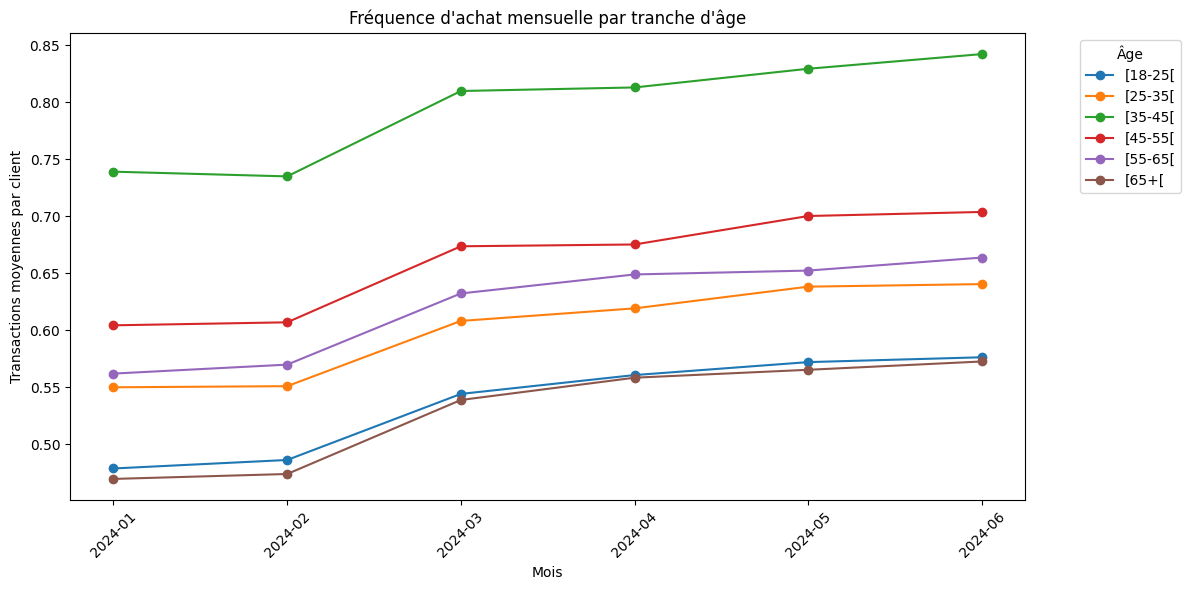

In [170]:
if "age" in customers.columns:

    # --- 1) Relier transactions et tranches d'âge ---
    retail_age = retailer.merge(
        customers[["customer_id", "age"]],
        on="customer_id",
        how="left"
    ).dropna(subset=["age"])

    # Extraire le mois (format AAAA-MM)
    retail_age["month"] = retail_age["timestamp_utc"].dt.to_period("M").astype(str)

    # --- 2) Agrégation par âge × mois ---
    freq_month_age = (
        retail_age
        .groupby(["age", "month"], as_index=False)
        .agg(
            total_transactions=("sales", "count"),      # nb d’achats
            unique_clients=("customer_id", "nunique"),  # nb de clients uniques
        )
        .assign(freq_per_client=lambda df: df["total_transactions"] / df["unique_clients"])
        .sort_values(["age", "month"])
    )

    print("Fréquence d'achat mensuelle par tranche d'âge :")
    display(freq_month_age.head())

    # --- 3) Visualisation ---
    plt.figure(figsize=(12, 6))

    for age_group, subset in freq_month_age.groupby("age"):
        plt.plot(subset["month"], subset["freq_per_client"], marker="o", label=str(age_group))

    plt.xlabel("Mois")
    plt.ylabel("Transactions moyennes par client")
    plt.title("Fréquence d'achat mensuelle par tranche d'âge")
    plt.xticks(rotation=45)
    plt.legend(title="Âge", bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.tight_layout()
    plt.show()

else:
    print("⚠️ Colonne 'age' absente de customers.")

## 7.5 Analyse fréquentielle de l'exposition

### Fréquence totale d'exposition par client (TV + Prog)

In [171]:
customers["total_impressions"] = customers["tv_impressions"] + customers["prog_impressions"]

# Bins de fréquence (à ajuster si besoin)
bins = [0, 1, 3, 5, 10, 20, 30, 40, 50, 60, 70, 80, 90, 100, 1000, 10000, 100000, np.inf]
labels = ["0", "1-2", "3-4", "5-9", "10-19", "20-29", "30-39", "40-49", "50-59", "60-69", "70-79", "80-89", "90-99", "100-999", "1000-9999", "10000-99999", "100000+"]

customers["freq_bin"] = pd.cut(
    customers["total_impressions"],
    bins=bins,
    labels=labels,
    include_lowest=True,
    right=False,
)

print("Répartition des clients par tranche de fréquence :")
display(
    customers["freq_bin"]
    .value_counts()
    .sort_index()
    .to_frame("nb_clients")
)

Répartition des clients par tranche de fréquence :


,nb_clients
freq_bin,
0,415828
1-2,445871
3-4,97142
5-9,98384
10-19,71331
20-29,25567
30-39,9241
40-49,4263
50-59,1997


#### KPIs par tranche de fréquence d'exposition

In [172]:


# Flag acheteur (au moins 1 vente sur la période)
customers_freq = customers.copy()
customers_freq["is_buyer"] = customers_freq["total_sales"] > 0

if "n_transactions" in customers_freq.columns:
    kpi_freq = (
        customers_freq
        .groupby("freq_bin", as_index=False)
        .agg(
            clients=("customer_id", "nunique"),
            buyers=("is_buyer", "sum"),
            total_sales=("total_sales", "sum"),
            mean_sales_per_client=("total_sales", "mean"),
            total_transactions=("n_transactions", "sum"),
            total_impressions_group=("total_impressions", "sum"),
        )
    )
elif "n_exposure" in customers_freq.columns:
    # si vous n'avez pas renommé la colonne plus haut
    kpi_freq = (
        customers_freq
        .groupby("freq_bin", as_index=False)
        .agg(
            clients=("customer_id", "nunique"),
            buyers=("is_buyer", "sum"),
            total_sales=("total_sales", "sum"),
            mean_sales_per_client=("total_sales", "mean"),
            total_transactions=("n_exposure", "sum"),
            total_impressions_group=("total_impressions", "sum"),
        )
    )
else:
    # fallback : sans info de nombre de transactions
    kpi_freq = (
        customers_freq
        .groupby("freq_bin", as_index=False)
        .agg(
            clients=("customer_id", "nunique"),
            buyers=("is_buyer", "sum"),
            total_sales=("total_sales", "sum"),
            mean_sales_per_client=("total_sales", "mean"),
            total_impressions_group=("total_impressions", "sum"),
        )
    )

# Taux de conversion
kpi_freq["conversion_rate"] = kpi_freq["buyers"] / kpi_freq["clients"]

# Panier moyen (si on a le nb de transactions)
if "total_transactions" in kpi_freq.columns:
    kpi_freq["basket_mean"] = kpi_freq["total_sales"] / kpi_freq["total_transactions"]

# CA par impression (efficacité marginale globale)
kpi_freq["sales_per_impression"] = kpi_freq["total_sales"] / kpi_freq["total_impressions_group"].replace(0, np.nan)

print("KPIs par tranche de fréquence d'exposition :")
display(kpi_freq)

/var/folders/g3/5kdl364n7mv9ntsl8b3md3mr0000gn/T/ipykernel_99058/4183686519.py:8: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby("freq_bin", as_index=False)


KPIs par tranche de fréquence d'exposition :


,freq_bin,clients,buyers,total_sales,mean_sales_per_client,total_transactions,total_impressions_group,conversion_rate,basket_mean,sales_per_impression
0,0,415828,173428,19438871.84,46.747386,2784933,0,0.417067,6.980014,NaN
1,1-2,445871,172204,21095163.19,47.312257,3412190,553350,0.386219,6.182294,38.122641
2,3-4,97142,30913,4153731.80,42.759381,737188,330536,0.318225,5.634562,12.566655
3,5-9,98384,30663,4137217.99,42.051736,689538,648593,0.311667,5.999985,6.378758
4,10-19,71331,19565,2890880.68,40.527690,484346,976384,0.274285,5.968627,2.960803
5,20-29,25567,4743,865342.92,33.846088,164924,604073,0.185513,5.246919,1.432514
6,30-39,9241,1230,246350.90,26.658468,54136,312786,0.133102,4.550593,0.787602
7,40-49,4263,395,72795.19,17.076047,21276,187143,0.092658,3.421470,0.388982
8,50-59,1997,181,30952.61,15.499554,10348,107612,0.090636,2.991168,0.287632
9,60-69,982,88,15737.25,16.025713,5364,62910,0.089613,2.933865,0.250155


### Graphiques : saturation par fréquence d'exposition

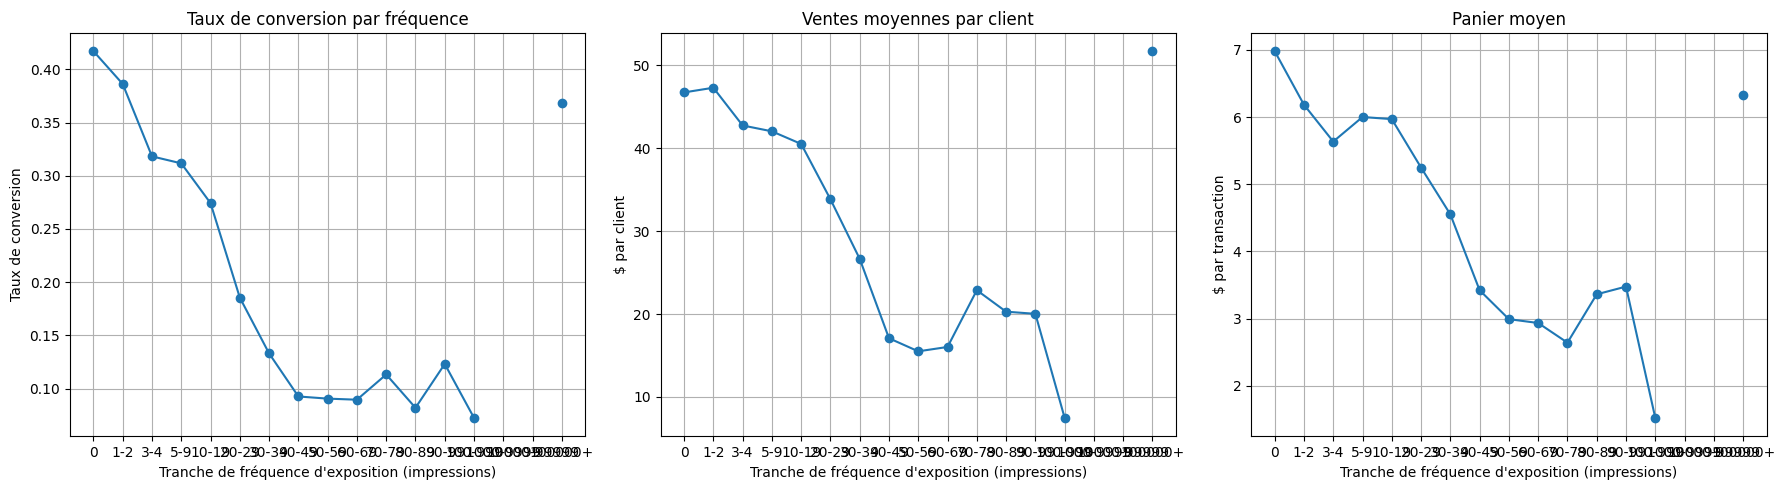

In [173]:

fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharex=True)

x = kpi_freq["freq_bin"].astype(str)

# 1) Taux de conversion
axes[0].plot(x, kpi_freq["conversion_rate"], marker="o")
axes[0].set_title("Taux de conversion par fréquence")
axes[0].set_ylabel("Taux de conversion")
axes[0].grid(True)

# 2) Valeur des ventes par client
axes[1].plot(x, kpi_freq["mean_sales_per_client"], marker="o")
axes[1].set_title("Ventes moyennes par client")
axes[1].set_ylabel("$ par client")
axes[1].grid(True)

# 3) Panier moyen OU CA par impression selon ce qui est dispo
if "basket_mean" in kpi_freq.columns:
    axes[2].plot(x, kpi_freq["basket_mean"], marker="o")
    axes[2].set_title("Panier moyen")
    axes[2].set_ylabel("$ par transaction")
else:
    axes[2].plot(x, kpi_freq["sales_per_impression"], marker="o")
    axes[2].set_title("CA par impression")
    axes[2].set_ylabel("$ par impression")

axes[2].grid(True)

for ax in axes:
    ax.set_xlabel("Tranche de fréquence d'exposition (impressions)")

plt.tight_layout()
plt.show()

Résultats bizarres.. on soupçonne une erreur dans le code pour cette partie..

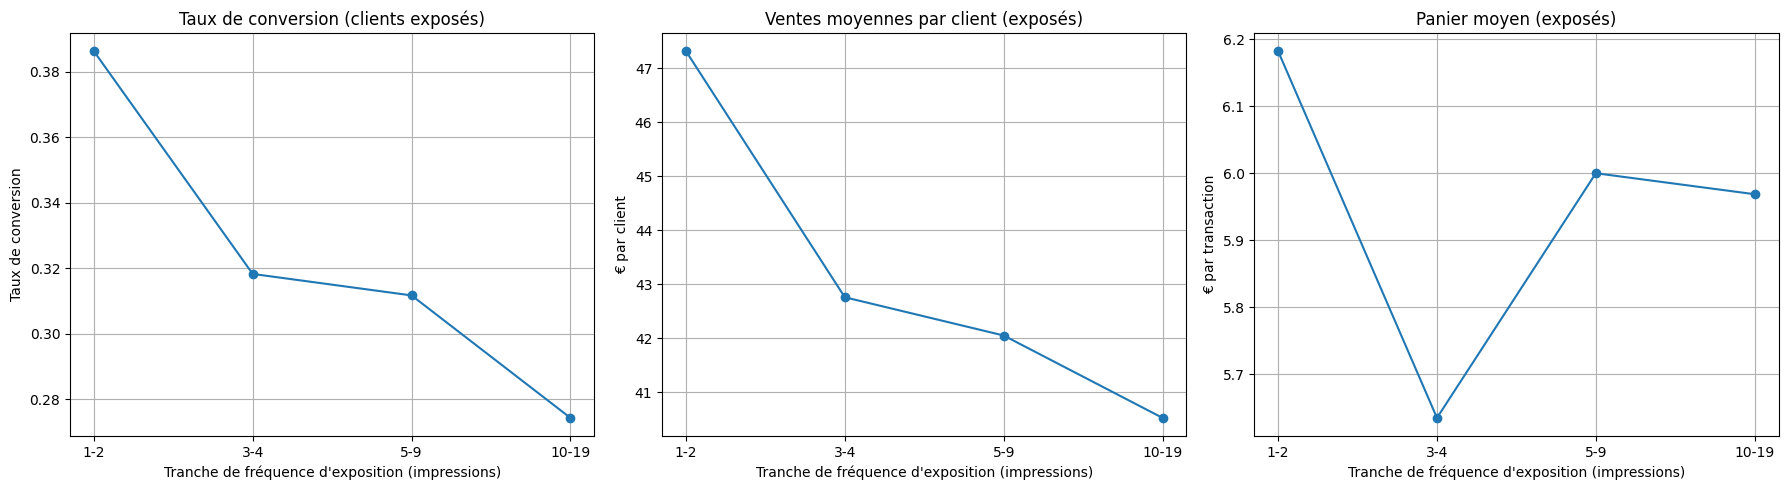

In [174]:
kpi_freq_exposed = kpi_freq[
    kpi_freq["freq_bin"].isin(["1-2", "3-4", "5-9", "10-19", "20-49"])
].copy()

fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharex=True)

x = kpi_freq_exposed["freq_bin"].astype(str)

axes[0].plot(x, kpi_freq_exposed["conversion_rate"], marker="o")
axes[0].set_title("Taux de conversion (clients exposés)")
axes[0].set_ylabel("Taux de conversion")
axes[0].grid(True)

axes[1].plot(x, kpi_freq_exposed["mean_sales_per_client"], marker="o")
axes[1].set_title("Ventes moyennes par client (exposés)")
axes[1].set_ylabel("€ par client")
axes[1].grid(True)

axes[2].plot(x, kpi_freq_exposed["basket_mean"], marker="o")
axes[2].set_title("Panier moyen (exposés)")
axes[2].set_ylabel("€ par transaction")
axes[2].grid(True)

for ax in axes:
    ax.set_xlabel("Tranche de fréquence d'exposition (impressions)")

plt.tight_layout()
plt.show()

## Modèle de saturation

In [175]:
# 1) Table pour le modèle de saturation TV

saturation_tv = (
    customers
    .groupby("tv_impressions", as_index=False)
    .agg(
        conversions=("n_transactions", "sum"),
        clients=("customer_id", "nunique")
    )
)

# Taux de conversion = nb de transactions / nb de clients
saturation_tv["conv_per_client"] = saturation_tv["conversions"] / saturation_tv["clients"]

print("Saturation TV - brut :")
display(saturation_tv.head())

Saturation TV - brut :


,tv_impressions,conversions,clients,conv_per_client
0,0,8843015,1200890,7.363718
1,1,400303,60884,6.574847
2,2,122407,19104,6.407402
3,3,61386,9427,6.511722
4,4,40692,6267,6.493059


In [176]:
sat_tv = saturation_tv.copy()

# On garde uniquement les clients exposés
sat_tv = sat_tv[sat_tv["tv_impressions"] > 0].copy()

# On vire les NaN / inf
sat_tv = sat_tv.replace([np.inf, -np.inf], np.nan).dropna(subset=["conv_per_client"])

# Optionnel : on coupe les extrêmes sur les impressions (p.ex. au 99e percentile)
p99 = sat_tv["tv_impressions"].quantile(0.99)
sat_tv = sat_tv[sat_tv["tv_impressions"] <= p99].copy()

print("Après nettoyage :")
display(sat_tv.describe())

Après nettoyage :


,tv_impressions,conversions,clients,conv_per_client
count,103.000000,103.000000,103.000000,103.000000
mean,55.815534,7197.679612,1103.747573,6.742708
std,37.353570,41632.436981,6347.704981,4.581191
min,1.000000,1.000000,1.000000,1.000000
25%,26.500000,11.000000,2.000000,4.717105
50%,52.000000,57.000000,9.000000,6.260940
75%,77.500000,555.500000,70.000000,7.517086
max,165.000000,400303.000000,60884.000000,35.000000


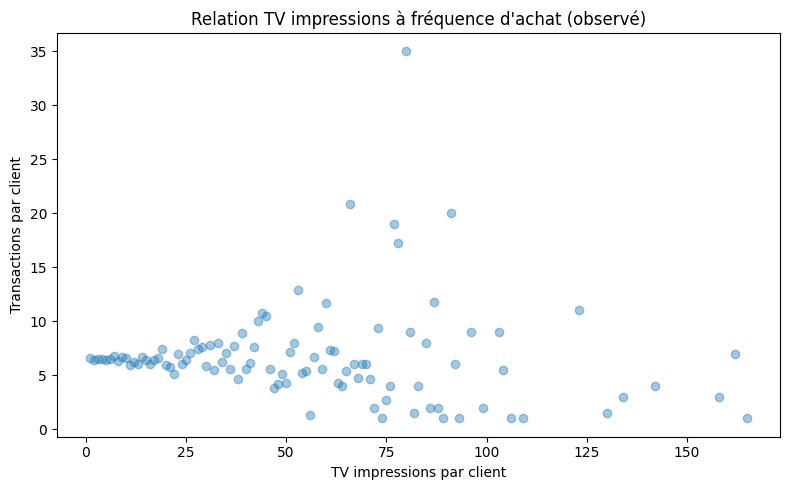

In [177]:
plt.figure(figsize=(8, 5))
plt.scatter(sat_tv["tv_impressions"], sat_tv["conv_per_client"], alpha=0.4)
plt.xlabel("TV impressions par client")
plt.ylabel("Transactions par client")
plt.title("Relation TV impressions à fréquence d'achat (observé)")
plt.tight_layout()
plt.show()

## Capping

In [178]:
df_cap = pd.read_csv("X_raffinee/optimal_capping_agg.csv")

# Nettoyer les virgules comme décimales si nécessaire
df_cap["imp_cost"] = df_cap["imp_cost"].astype(str).str.replace(",", ".").astype(float)
df_cap["sales"] = df_cap["sales"].astype(str).str.replace(",", ".").astype(float)
df_cap["imp_cost_brackets"] = df_cap["imp_cost_brackets"].astype(str).str.replace(",", ".").astype(float)
df_cap["sales_brackets"] = df_cap["sales_brackets"].astype(str).str.replace(",", ".").astype(float)
df_cap["nb_users_brackets"] = df_cap["nb_users_brackets"].astype(int)

df_cap

,nb_imp_bracket,imp_cost,sales,dsp_id,imp_cost_brackets,nb_users_brackets,sales_brackets
0,1,485159.945210,2701404.74,3693977,4.851599e+05,3693977,2701404.74
1,2,220758.412321,1001390.61,1008217,7.059184e+05,4702194,3702795.35
2,3,147852.452234,520591.96,505091,8.537708e+05,5207285,4223387.31
3,4-5,217186.550984,625689.26,529454,1.070957e+06,5736739,4849076.57
4,6-10,323564.808662,822511.92,486283,1.394522e+06,6223022,5671588.49
5,11-15,185632.620293,461389.53,179017,1.580155e+06,6402039,6132978.02
6,16-20,122215.613292,302864.37,87875,1.702370e+06,6489914,6435842.39
7,21-25,80530.514530,180439.10,45948,1.782901e+06,6535862,6616281.49
8,26-35,90843.223145,166932.57,38936,1.873744e+06,6574798,6783214.06
9,36-45,43840.186227,59487.14,14172,1.917584e+06,6588970,6842701.20


In [179]:
df_cap["sales_per_user"] = df_cap["sales_brackets"] / df_cap["nb_users_brackets"]
df_cap["cost_per_user"] = df_cap["imp_cost_brackets"] / df_cap["nb_users_brackets"]

df_cap["roi"] = df_cap["sales_brackets"] / df_cap["imp_cost_brackets"]

# Marginal lift (incrément vs bracket précédent)
df_cap["sales_smooth"] = (
    df_cap["sales_per_user"]
    .rolling(window=3, center=True, min_periods=1)
    .mean()
)
df_cap["marginal_smooth"] = df_cap["sales_smooth"].diff()

# baseline = croissance moyenne sur les 3 premiers sauts
baseline = df_cap["marginal_smooth"].iloc[1:4].mean()
threshold_rel = 0.10  # 10 % de la croissance initiale
threshold = baseline * threshold_rel

df_cap["is_saturated_marginal"] = df_cap["marginal_smooth"] < threshold


df_cap

,nb_imp_bracket,imp_cost,sales,dsp_id,imp_cost_brackets,nb_users_brackets,sales_brackets,sales_per_user,cost_per_user,roi,sales_smooth,marginal_smooth,is_saturated_marginal
0,1,485159.945210,2701404.74,3693977,4.851599e+05,3693977,2701404.74,0.731300,0.131338,5.568070,0.759381,NaN,False
1,2,220758.412321,1001390.61,1008217,7.059184e+05,4702194,3702795.35,0.787461,0.150125,5.245359,0.776605,0.017224,False
2,3,147852.452234,520591.96,505091,8.537708e+05,5207285,4223387.31,0.811054,0.163957,4.946746,0.814594,0.037989,False
3,4-5,217186.550984,625689.26,529454,1.070957e+06,5736739,4849076.57,0.845267,0.186684,4.527796,0.855903,0.041309,False
4,6-10,323564.808662,822511.92,486283,1.394522e+06,6223022,5671588.49,0.911388,0.224091,4.067048,0.904876,0.048973,False
5,11-15,185632.620293,461389.53,179017,1.580155e+06,6402039,6132978.02,0.957973,0.246821,3.881251,0.953676,0.048800,False
6,16-20,122215.613292,302864.37,87875,1.702370e+06,6489914,6435842.39,0.991668,0.262310,3.780518,0.987315,0.033639,False
7,21-25,80530.514530,180439.10,45948,1.782901e+06,6535862,6616281.49,1.012304,0.272787,3.710964,1.011891,0.024576,False
8,26-35,90843.223145,166932.57,38936,1.873744e+06,6574798,6783214.06,1.031699,0.284989,3.620139,1.027504,0.015613,False
9,36-45,43840.186227,59487.14,14172,1.917584e+06,6588970,6842701.20,1.038508,0.291029,3.568396,1.037190,0.009686,False


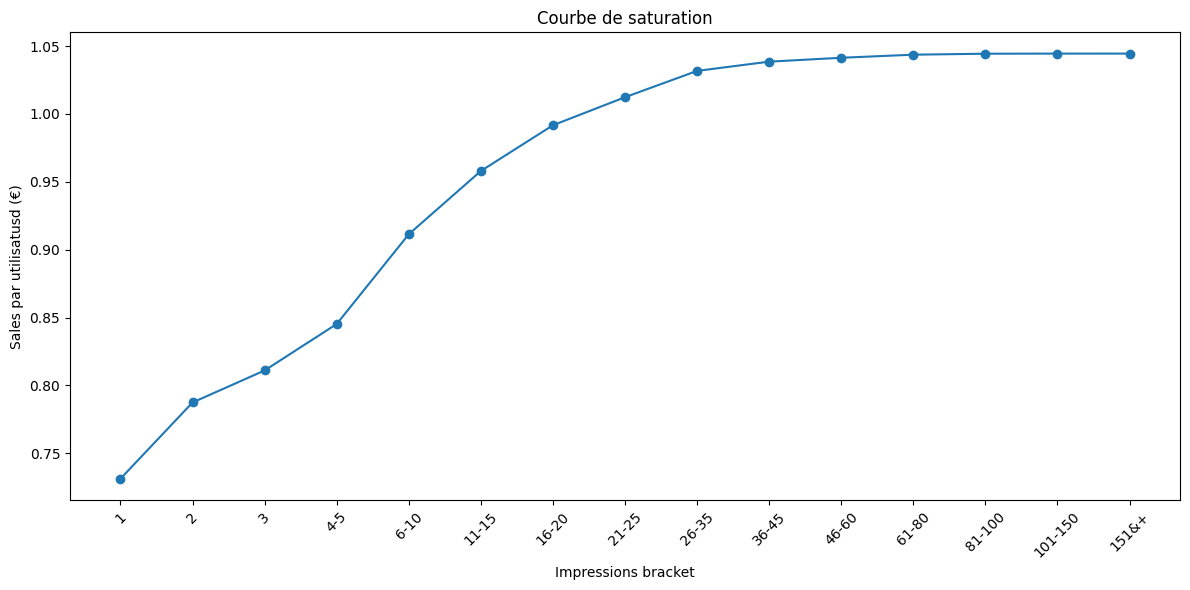

In [180]:
plt.figure(figsize=(12,6))
plt.plot(df_cap["nb_imp_bracket"], df_cap["sales_per_user"], marker="o")
plt.xticks(rotation=45)
plt.ylabel("Sales par utilisatusd (€)")
plt.xlabel("Impressions bracket")
plt.title("Courbe de saturation")
plt.tight_layout()
plt.show()

In [181]:
# 5) Méthode plateau : point où on atteint 95 % du plateau final
plateau = df_cap["sales_smooth"].tail(3).mean()
df_cap["close_to_plateau"] = df_cap["sales_smooth"] >= 0.95 * plateau

cap_opt_plateau = None
if df_cap["close_to_plateau"].any():
    cap_opt_plateau = df_cap.loc[df_cap["close_to_plateau"]].iloc[0]["nb_imp_bracket"]

cap_opt_marginal = None
if df_cap["is_saturated_marginal"].any():
    cap_opt_marginal = df_cap.loc[df_cap["is_saturated_marginal"]].iloc[0]["nb_imp_bracket"]

print("Table capping avec KPI :")
display(df_cap)

print("\nPlateau (≈ moyenne des 3 derniers brackets) :", plateau)
print("Capping optimal (méthode plateau 95%) :", cap_opt_plateau)
print("Capping 'saturation marginale' (moins robuste) :", cap_opt_marginal)

Table capping avec KPI :


,nb_imp_bracket,imp_cost,sales,dsp_id,imp_cost_brackets,nb_users_brackets,sales_brackets,sales_per_user,cost_per_user,roi,sales_smooth,marginal_smooth,is_saturated_marginal,close_to_plateau
0,1,485159.945210,2701404.74,3693977,4.851599e+05,3693977,2701404.74,0.731300,0.131338,5.568070,0.759381,NaN,False,False
1,2,220758.412321,1001390.61,1008217,7.059184e+05,4702194,3702795.35,0.787461,0.150125,5.245359,0.776605,0.017224,False,False
2,3,147852.452234,520591.96,505091,8.537708e+05,5207285,4223387.31,0.811054,0.163957,4.946746,0.814594,0.037989,False,False
3,4-5,217186.550984,625689.26,529454,1.070957e+06,5736739,4849076.57,0.845267,0.186684,4.527796,0.855903,0.041309,False,False
4,6-10,323564.808662,822511.92,486283,1.394522e+06,6223022,5671588.49,0.911388,0.224091,4.067048,0.904876,0.048973,False,False
5,11-15,185632.620293,461389.53,179017,1.580155e+06,6402039,6132978.02,0.957973,0.246821,3.881251,0.953676,0.048800,False,False
6,16-20,122215.613292,302864.37,87875,1.702370e+06,6489914,6435842.39,0.991668,0.262310,3.780518,0.987315,0.033639,False,False
7,21-25,80530.514530,180439.10,45948,1.782901e+06,6535862,6616281.49,1.012304,0.272787,3.710964,1.011891,0.024576,False,True
8,26-35,90843.223145,166932.57,38936,1.873744e+06,6574798,6783214.06,1.031699,0.284989,3.620139,1.027504,0.015613,False,True
9,36-45,43840.186227,59487.14,14172,1.917584e+06,6588970,6842701.20,1.038508,0.291029,3.568396,1.037190,0.009686,False,True



Plateau (≈ moyenne des 3 derniers brackets) : 1.0443281609504345
Capping optimal (méthode plateau 95%) : 21-25
Capping 'saturation marginale' (moins robuste) : 61-80


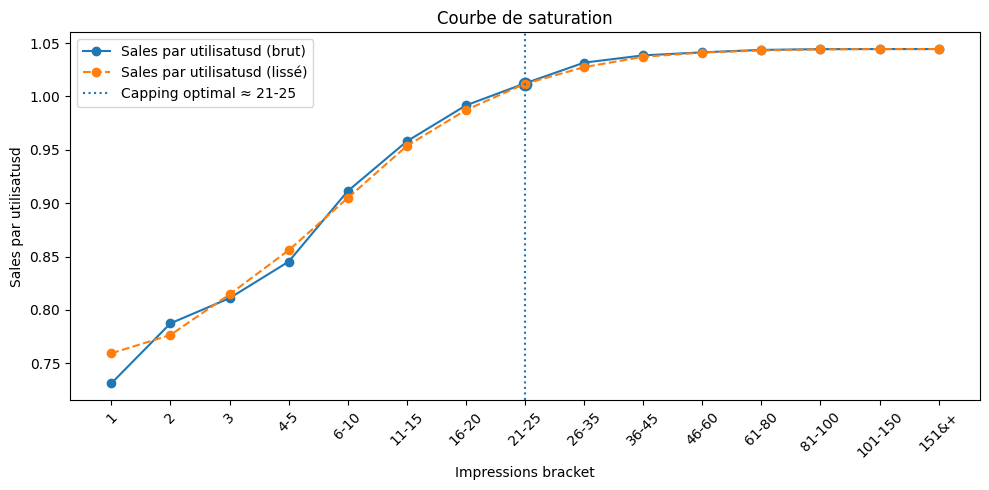

In [182]:
plt.figure(figsize=(10, 5))
plt.plot(
    df_cap["nb_imp_bracket"].astype(str),
    df_cap["sales_per_user"],
    marker="o",
    label="Sales par utilisatusd (brut)",
)
plt.plot(
    df_cap["nb_imp_bracket"].astype(str),
    df_cap["sales_smooth"],
    marker="o",
    linestyle="--",
    label="Sales par utilisatusd (lissé)",
)

if cap_opt_plateau is not None:
    # marquer visuellement le capping choisi
    x_cap = str(cap_opt_plateau)
    idx_cap = df_cap.index[df_cap["nb_imp_bracket"] == cap_opt_plateau][0]
    y_cap = df_cap.loc[idx_cap, "sales_smooth"]
    plt.axvline(x=x_cap, linestyle=":", label=f"Capping optimal ≈ {x_cap}")
    plt.scatter(x_cap, y_cap, s=80)

plt.xticks(rotation=45)
plt.ylabel("Sales par utilisatusd")
plt.xlabel("Impressions bracket")
plt.title("Courbe de saturation")
plt.legend()
plt.tight_layout()
plt.show()


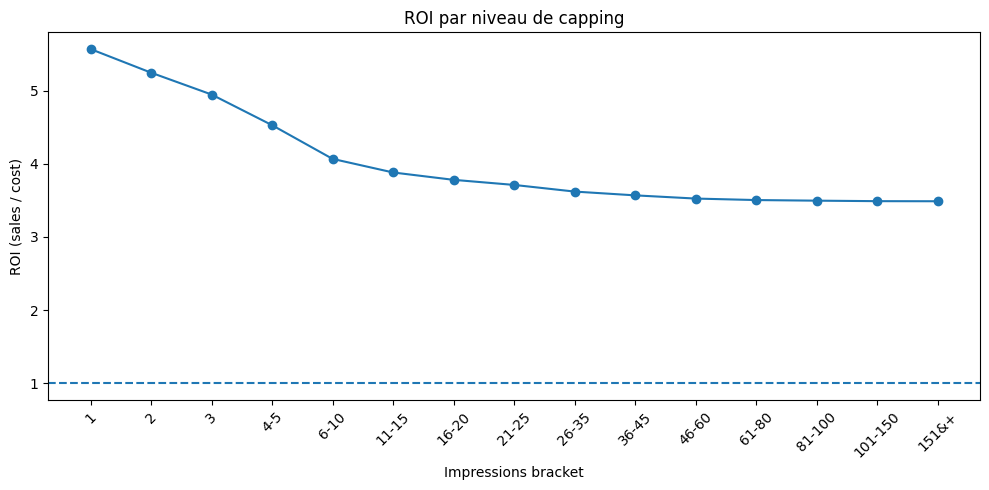

In [183]:
#Plot 2 : ROI par niveau de capping
plt.figure(figsize=(10, 5))
plt.plot(
    df_cap["nb_imp_bracket"].astype(str),
    df_cap["roi"],
    marker="o",
)
plt.xticks(rotation=45)
plt.ylabel("ROI (sales / cost)")
plt.xlabel("Impressions bracket")
plt.title("ROI par niveau de capping")
plt.axhline(1.0, linestyle="--")  # seuil ROI = 1
plt.tight_layout()
plt.show()

In [184]:
df = pd.read_csv("X_raffinee/optimal_capping_granular_raffined.csv")
print(df.head())

/var/folders/g3/5kdl364n7mv9ntsl8b3md3mr0000gn/T/ipykernel_99058/66880282.py:1: DtypeWarning: Columns (3) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("X_raffinee/optimal_capping_granular_raffined.csv")


                           dsp_id             imp_date  imp_cost order_date  sales
0  dsp9tnGII5BeXbn6LUSFZPcKGCyI0F  2024-04-23 21:09:46   2325.51        NaN    NaN
1  dspdRM4QgzQzPYI4gNJrDLqfRug9Ry  2024-04-19 18:31:30   2325.51        NaN    NaN
2  dsp5VkQ9hX5dI5iaN5LAcvsty95ujR  2024-06-28 00:10:10   2325.51        NaN    NaN
3  dsp5VkQ9hX5dI5iaN5LAcvsty95ujR  2024-06-28 00:10:10   2325.51        NaN    NaN
4  dspxilCjPSIOpesNAJXrRjwngcC6cn  2024-05-24 03:45:45   2325.51        NaN    NaN
